In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

print("Everything imported successfully!")

Everything imported successfully!


In [2]:
# Load a world map that comes built into geopandas
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))

# Inspect the data - just like head() in R
print(world.shape)
world.head()

AttributeError: The geopandas.dataset has been deprecated and was removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.

In [ ]:
import geodatasets

path = geodatasets.get_path('naturalearth.land')
world = gpd.read_file(path)

print(world.shape)
world.head()

In [ ]:
world.plot(figsize=(12, 6), color='lightgreen', edgecolor='gray', linewidth=0.5)
plt.title('World Map')
plt.axis('off')
plt.show()

In [3]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

print("Libraries ready!")

Libraries ready!


In [4]:
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)
print(world.shape)
print(world.columns.tolist())

(177, 169)
['featurecla', 'scalerank', 'LABELRANK', 'SOVEREIGNT', 'SOV_A3', 'ADM0_DIF', 'LEVEL', 'TYPE', 'TLC', 'ADMIN', 'ADM0_A3', 'GEOU_DIF', 'GEOUNIT', 'GU_A3', 'SU_DIF', 'SUBUNIT', 'SU_A3', 'BRK_DIFF', 'NAME', 'NAME_LONG', 'BRK_A3', 'BRK_NAME', 'BRK_GROUP', 'ABBREV', 'POSTAL', 'FORMAL_EN', 'FORMAL_FR', 'NAME_CIAWF', 'NOTE_ADM0', 'NOTE_BRK', 'NAME_SORT', 'NAME_ALT', 'MAPCOLOR7', 'MAPCOLOR8', 'MAPCOLOR9', 'MAPCOLOR13', 'POP_EST', 'POP_RANK', 'POP_YEAR', 'GDP_MD', 'GDP_YEAR', 'ECONOMY', 'INCOME_GRP', 'FIPS_10', 'ISO_A2', 'ISO_A2_EH', 'ISO_A3', 'ISO_A3_EH', 'ISO_N3', 'ISO_N3_EH', 'UN_A3', 'WB_A2', 'WB_A3', 'WOE_ID', 'WOE_ID_EH', 'WOE_NOTE', 'ADM0_ISO', 'ADM0_DIFF', 'ADM0_TLC', 'ADM0_A3_US', 'ADM0_A3_FR', 'ADM0_A3_RU', 'ADM0_A3_ES', 'ADM0_A3_CN', 'ADM0_A3_TW', 'ADM0_A3_IN', 'ADM0_A3_NP', 'ADM0_A3_PK', 'ADM0_A3_DE', 'ADM0_A3_GB', 'ADM0_A3_BR', 'ADM0_A3_IL', 'ADM0_A3_PS', 'ADM0_A3_SA', 'ADM0_A3_EG', 'ADM0_A3_MA', 'ADM0_A3_PT', 'ADM0_A3_AR', 'ADM0_A3_JP', 'ADM0_A3_KO', 'ADM0_A3_VN', 'ADM0_

In [5]:
# Keep only the columns relevant to our project
cols = ['NAME', 'ISO_A3', 'CONTINENT', 'SUBREGION', 'INCOME_GRP', 'ECONOMY', 'POP_EST', 'GDP_MD', 'geometry']
world_clean = world[cols].copy()

# Rename for readability
world_clean.columns = ['name', 'iso3', 'continent', 'subregion', 'income_group', 'economy', 'pop_est', 'gdp_md', 'geometry']

print(world_clean.shape)
world_clean.head(10)

(177, 9)


,name,iso3,continent,subregion,income_group,economy,pop_est,gdp_md,geometry
0,Fiji,FJI,Oceania,Melanesia,4. Lower middle income,6. Developing region,889953.0,5496,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ..."
1,Tanzania,TZA,Africa,Eastern Africa,5. Low income,7. Least developed region,58005463.0,63177,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3..."
2,W. Sahara,ESH,Africa,Northern Africa,5. Low income,7. Least developed region,603253.0,907,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948..."
3,Canada,CAN,North America,Northern America,1. High income: OECD,1. Developed region: G7,37589262.0,1736425,"MULTIPOLYGON (((-122.84 49, -122.97421 49.0025..."
4,United States of America,USA,North America,Northern America,1. High income: OECD,1. Developed region: G7,328239523.0,21433226,"MULTIPOLYGON (((-122.84 49, -120 49, -117.0312..."
5,Kazakhstan,KAZ,Asia,Central Asia,3. Upper middle income,6. Developing region,18513930.0,181665,"POLYGON ((87.35997 49.21498, 86.59878 48.54918..."
6,Uzbekistan,UZB,Asia,Central Asia,4. Lower middle income,6. Developing region,33580650.0,57921,"POLYGON ((55.96819 41.30864, 55.92892 44.99586..."
7,Papua New Guinea,PNG,Oceania,Melanesia,4. Lower middle income,6. Developing region,8776109.0,24829,"MULTIPOLYGON (((141.00021 -2.60015, 142.73525 ..."
8,Indonesia,IDN,Asia,South-Eastern Asia,4. Lower middle income,4. Emerging region: MIKT,270625568.0,1119190,"MULTIPOLYGON (((141.00021 -2.60015, 141.01706 ..."
9,Argentina,ARG,South America,South America,3. Upper middle income,5. Emerging region: G20,44938712.0,445445,"MULTIPOLYGON (((-68.63401 -52.63637, -68.25 -5..."


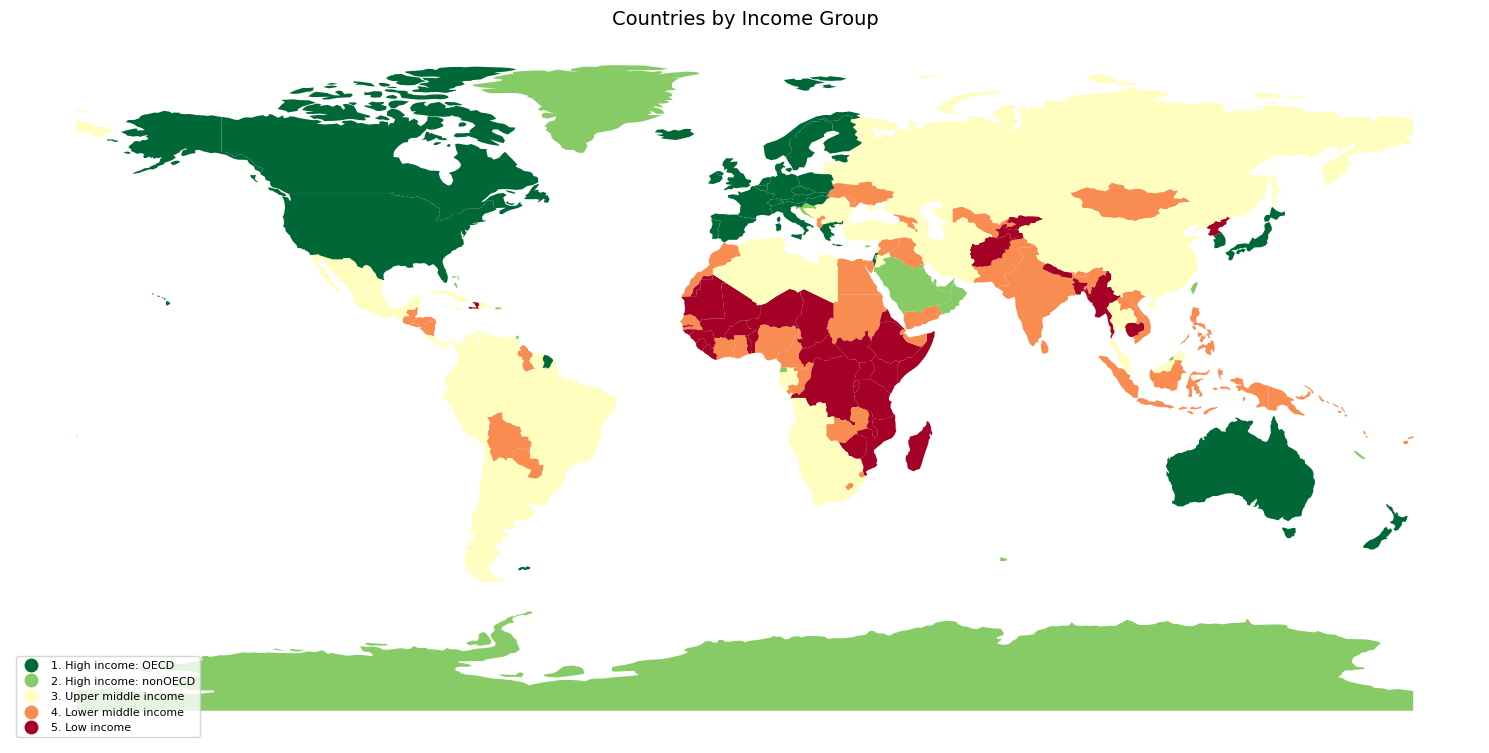

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(15, 8))

world_clean.plot(
    column='income_group',
    ax=ax,
    legend=True,
    legend_kwds={'loc': 'lower left', 'fontsize': 8},
    cmap='RdYlGn_r',
    missing_kwds={'color': 'lightgrey', 'label': 'No data'}
)

ax.set_title('Countries by Income Group', fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.show()

In [7]:
water_raw = pd.read_csv('API_ER.H2O.INTR.PC_DS2_en_csv_v2_260481.csv', skiprows=4)
print(water_raw.shape)
water_raw.head()

(266, 71)


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,Renewable internal freshwater resources per ca...,ER.H2O.INTR.PC,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,Renewable internal freshwater resources per ca...,ER.H2O.INTR.PC,NaN,18494.091264,17999.335237,17514.787770,17034.613509,16561.430486,...,3102.243905,3018.561579,2937.506056,2859.260825,2784.493962,2713.293548,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,Renewable internal freshwater resources per ca...,ER.H2O.INTR.PC,NaN,NaN,5013.607452,4909.163811,4804.205448,4698.083142,...,1321.137770,1283.236261,1245.505317,1206.839831,1178.737859,1161.935572,NaN,NaN,NaN,NaN
3,Africa Western and Central,AFW,Renewable internal freshwater resources per ca...,ER.H2O.INTR.PC,NaN,19040.250004,18638.697637,18238.592053,17844.419939,17453.287331,...,4305.995933,4198.268797,4097.068709,4000.342618,3906.890239,3816.825355,NaN,NaN,NaN,NaN
4,Angola,AGO,Renewable internal freshwater resources per ca...,ER.H2O.INTR.PC,NaN,27916.190315,27641.283377,27365.244660,27085.456629,26801.975595,...,4895.015317,4728.864333,4571.339333,4424.364473,4285.826520,4153.216769,NaN,NaN,NaN,NaN


In [8]:
# Keep only the columns we need
water = water_raw[['Country Name', 'Country Code']].copy()

# Get the most recent non-null value for each country across all year columns
year_cols = [col for col in water_raw.columns if col.isdigit()]
water['freshwater_per_capita'] = water_raw[year_cols].apply(lambda row: row.dropna().iloc[-1] if row.dropna().any() else None, axis=1)

print(water.shape)
water.head(10)

(266, 3)


,Country Name,Country Code,freshwater_per_capita
0,Aruba,ABW,NaN
1,Africa Eastern and Southern,AFE,2713.293548
2,Afghanistan,AFG,1161.935572
3,Africa Western and Central,AFW,3816.825355
4,Angola,AGO,4153.216769
5,Albania,ALB,10972.265051
6,Andorra,AND,3959.601029
7,Arab World,ARB,240.111452
8,United Arab Emirates,ARE,14.888371
9,Argentina,ARG,6430.598514


In [9]:
world_water = pd.merge(
    left=world_clean,
    right=water,
    left_on='iso3',
    right_on='Country Code',
    how='left'
)

print(world_water.shape)
world_water.head()

(177, 12)


,name,iso3,continent,subregion,income_group,economy,pop_est,gdp_md,geometry,Country Name,Country Code,freshwater_per_capita
0,Fiji,FJI,Oceania,Melanesia,4. Lower middle income,6. Developing region,889953.0,5496,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ...",Fiji,FJI,31052.117526
1,Tanzania,TZA,Africa,Eastern Africa,5. Low income,7. Least developed region,58005463.0,63177,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3...",Tanzania,TZA,1298.062683
2,W. Sahara,ESH,Africa,Northern Africa,5. Low income,7. Least developed region,603253.0,907,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948...",NaN,NaN,NaN
3,Canada,CAN,North America,Northern America,1. High income: OECD,1. Developed region: G7,37589262.0,1736425,"MULTIPOLYGON (((-122.84 49, -122.97421 49.0025...",Canada,CAN,73197.165374
4,United States of America,USA,North America,Northern America,1. High income: OECD,1. Developed region: G7,328239523.0,21433226,"MULTIPOLYGON (((-122.84 49, -120 49, -117.0312...",United States,USA,8436.688228


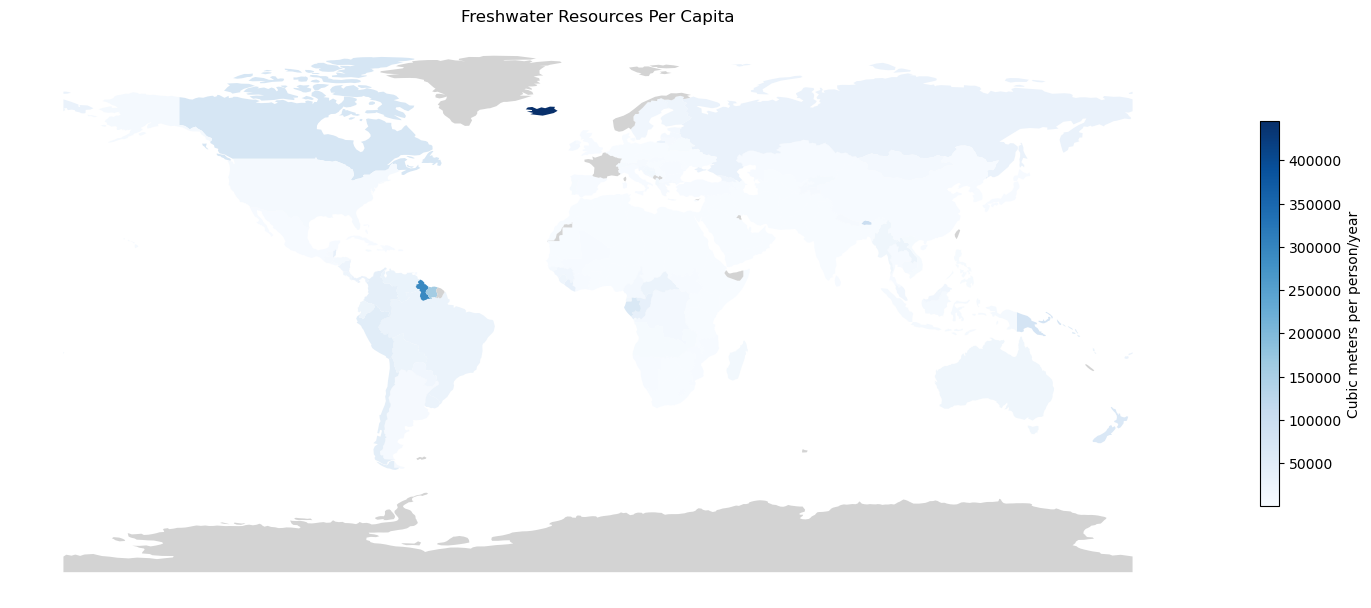

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(15, 8))

world_water.plot(
    column='freshwater_per_capita',
    ax=ax,
    legend=True,
    legend_kwds={'shrink': 0.5, 'label': 'Cubic meters per person/year'},
    cmap='Blues',
    missing_kwds={'color': 'lightgrey', 'label': 'No data'}
)

ax.set_title('Freshwater Resources Per Capita')
ax.axis('off')
plt.tight_layout()
plt.show()